In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [21]:
colors = {
    'successful': '#F28E2B',
    'unsuccessful': '#4E79A7'
}

In [2]:
# Set standard styling for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

In [3]:
# Load the cleaned dataset
df = pd.read_csv("../Data/kickstarter_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372066 entries, 0 to 372065
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                372066 non-null  int64  
 1   name              372062 non-null  object 
 2   category          372066 non-null  object 
 3   main_category     372066 non-null  object 
 4   currency          372066 non-null  object 
 5   deadline          372066 non-null  object 
 6   goal              372066 non-null  float64
 7   launched          372066 non-null  object 
 8   pledged           372066 non-null  float64
 9   state             372066 non-null  object 
 10  backers           372066 non-null  int64  
 11  country           372066 non-null  object 
 12  usd_pledged_real  372066 non-null  float64
 13  usd_goal_real     372066 non-null  float64
 14  duration          372066 non-null  int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 42.6+ MB


In [4]:
# convert date columns to datetime objects
df['deadline'] = pd.to_datetime(df['deadline'])
df['launched'] = pd.to_datetime(df['launched'])

In [5]:
# moving suspended, canceled, and undefined into unsuccessful bucket
def map_state(state):
    if state == 'successful':
        return 'successful'
    else:
        return 'unsuccessful'

df['target'] = df['state'].apply(map_state)

In [6]:
# Create log-transformed version of the goal
df['log_usd_goal_real'] = np.log1p(df['usd_goal_real'])
df['target'].value_counts()

target
unsuccessful    238215
successful      133851
Name: count, dtype: int64

In [7]:
df.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd_pledged_real,usd_goal_real,duration,target,log_usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,1533.95,58,unsuccessful,7.336253
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,2421.0,30000.00,59,unsuccessful,10.308986
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,45000.00,44,unsuccessful,10.714440
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,5000.00,29,unsuccessful,8.517393
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,19500.00,55,unsuccessful,9.878221


Exploring Single Variables

In [8]:
#Get percentages
df['target'].value_counts(normalize=True) * 100

target
unsuccessful    64.024931
successful      35.975069
Name: proportion, dtype: float64

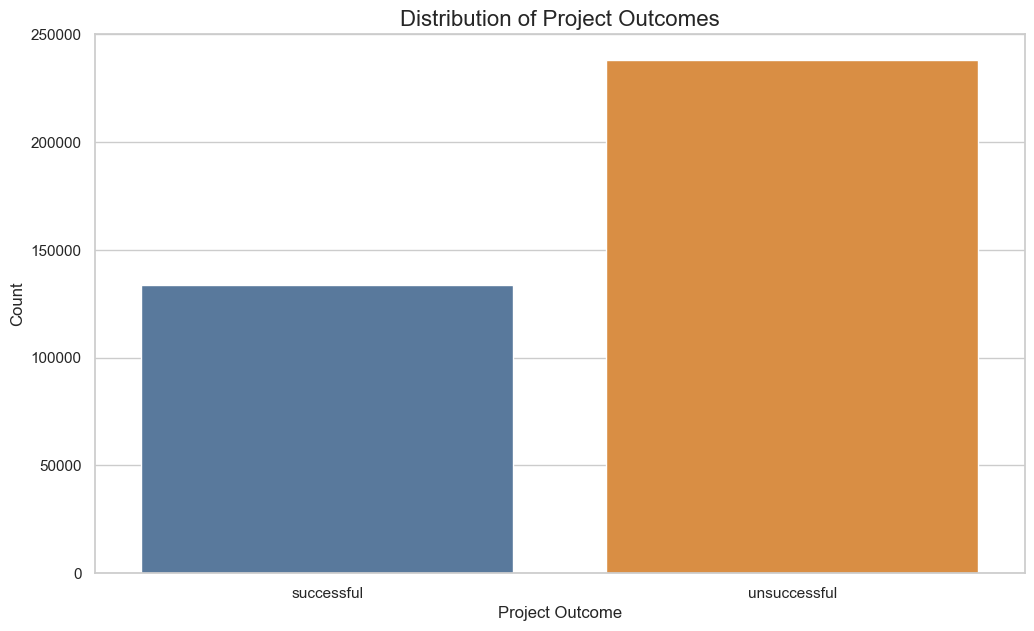

In [23]:
# Plot the count
sns.countplot(data=df, x='target', hue='target', order=['successful', 'unsuccessful'],palette=[colors['successful'], colors['unsuccessful']])
plt.title('Distribution of Project Outcomes', fontsize=16)
plt.ylabel('Count')
plt.xlabel('Project Outcome')
plt.show()

There are significantly more 'unsuccessful' projects (approx. 64%) than 'successful' ones (approx. 36%)

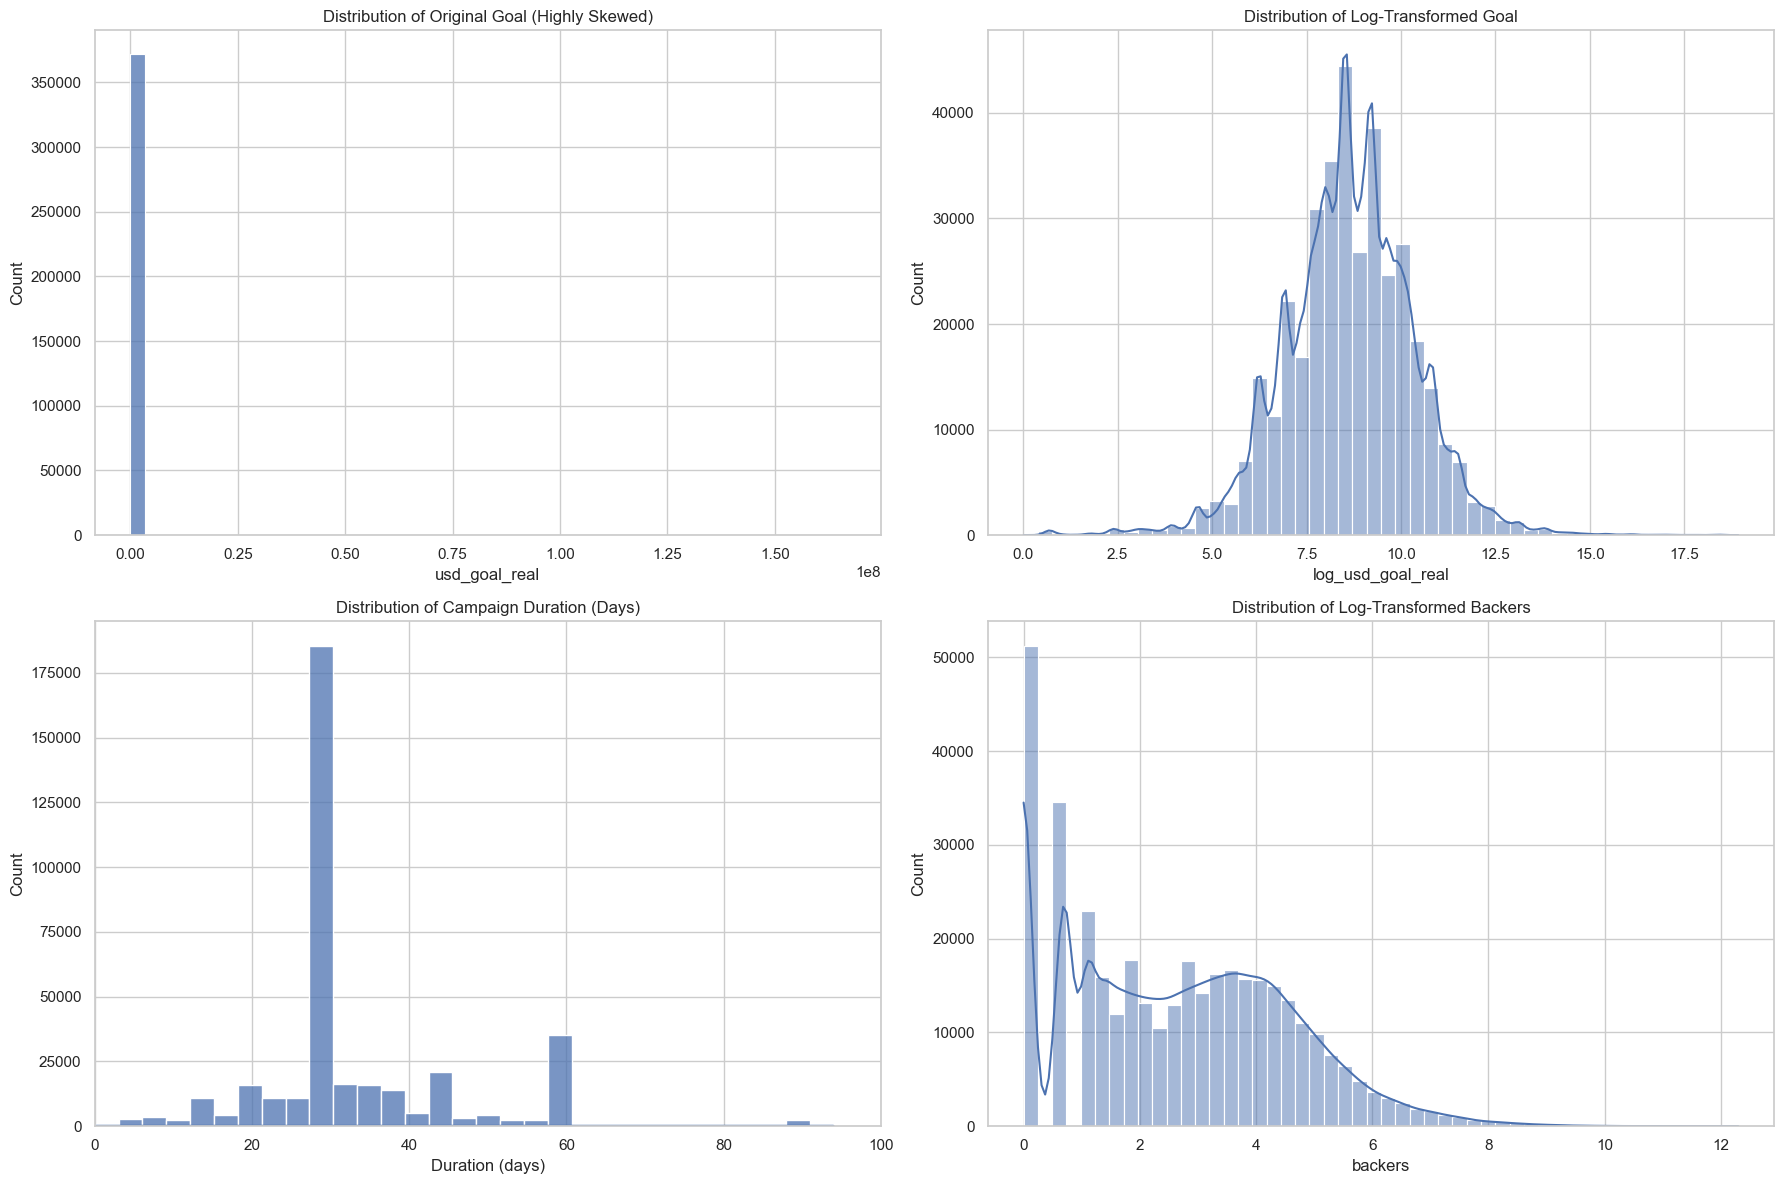

In [10]:
# Create a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Original Goal
sns.histplot(df['usd_goal_real'], bins=50, ax=axes[0, 0], kde=False)
axes[0, 0].set_title('Distribution of Original Goal (Highly Skewed)')

# Plot 2: Log-Transformed Goal
sns.histplot(df['log_usd_goal_real'], bins=50, ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Distribution of Log-Transformed Goal')

# Plot 3: Duration
df_duration = df[df['duration'] <= 100]
sns.histplot(df_duration['duration'], bins=30, ax=axes[1, 0], kde=False)
sns.kdeplot(df_duration['duration'], ax=axes[1, 0], linewidth=2)
axes[1, 0].set_title('Distribution of Campaign Duration (Days)')
axes[1, 0].set_xlabel("Duration (days)")
axes[1, 0].set_xlim(0, 100)

# Plot 4: Log-Transformed Backers
sns.histplot(np.log1p(df['backers']), bins=50, ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Distribution of Log-Transformed Backers')

plt.tight_layout()
plt.show()

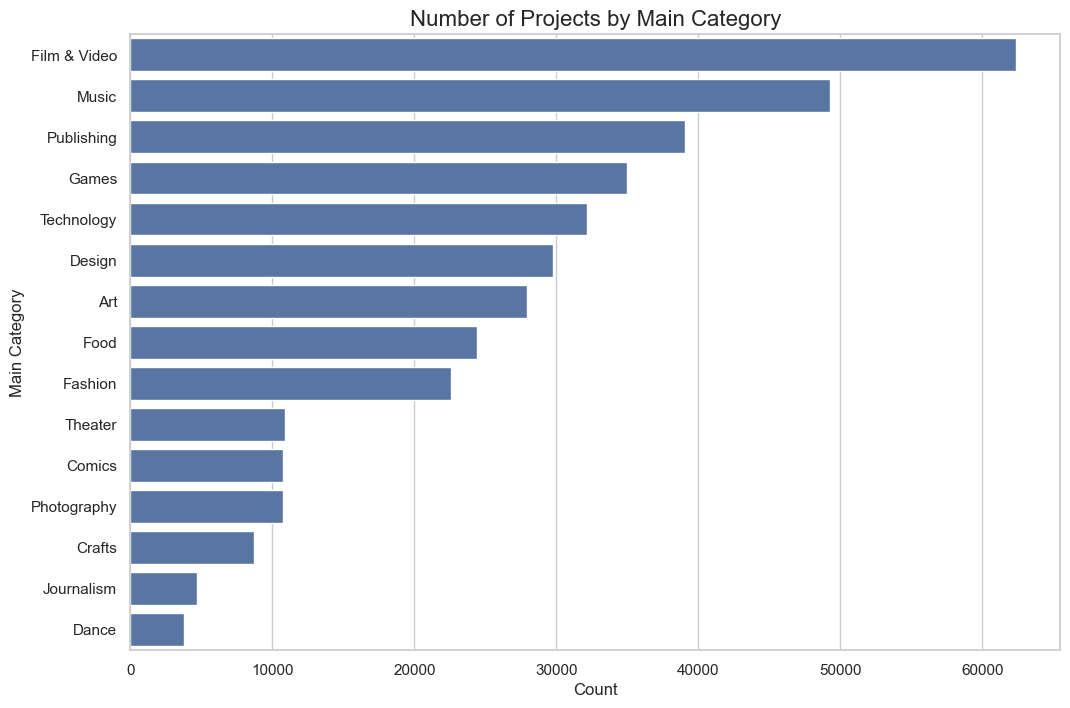

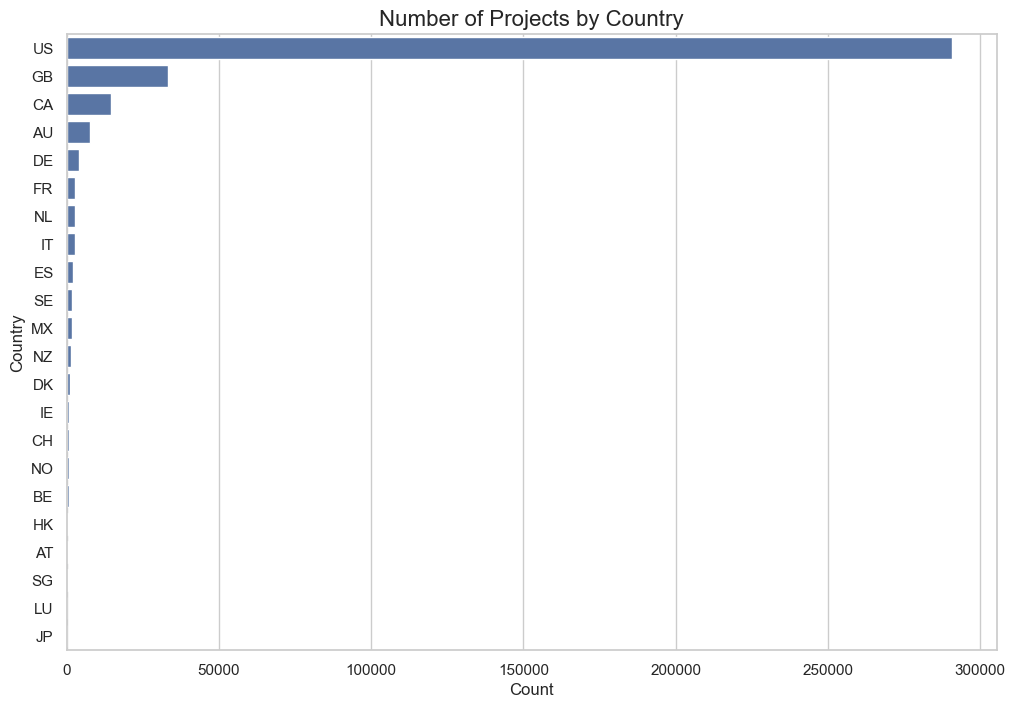

In [11]:
# Plot for 'main_category'
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='main_category', order=df['main_category'].value_counts().index)
plt.title('Number of Projects by Main Category', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Main Category')
plt.show()

# Plot for 'country'
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='country', order=df['country'].value_counts().index)
plt.title('Number of Projects by Country', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

'Film & Video' and 'Music' are the most common project categories, followed by 'Publishing' and 'Games'. Most projects are from the 'US', with 'GB' being a distant second.

Are there significant differences between subgroups?

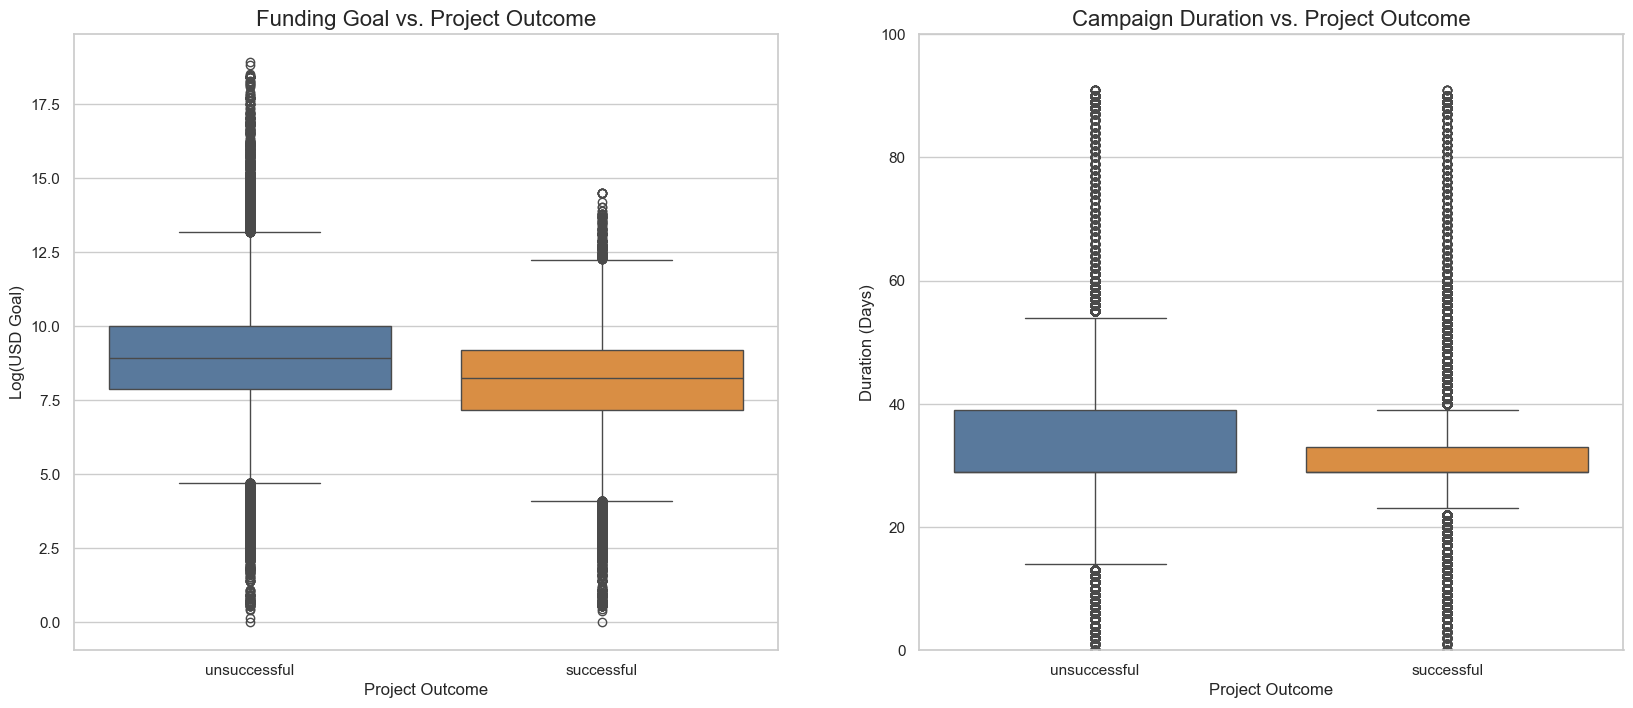

In [25]:
# Create a 1x2 grid for our plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Log-Transformed Goal vs. Target
sns.boxplot(data=df, x='target', y='log_usd_goal_real',hue='target',palette=colors, ax=axes[0])
axes[0].set_title('Funding Goal vs. Project Outcome', fontsize=16)
axes[0].set_xlabel('Project Outcome')
axes[0].set_ylabel('Log(USD Goal)')

# Plot 2: Duration vs. Target
sns.boxplot(data=df, x='target', y='duration', hue='target',palette=colors, ax=axes[1])
axes[1].set_title('Campaign Duration vs. Project Outcome', fontsize=16)
axes[1].set_xlabel('Project Outcome')
axes[1].set_ylabel('Duration (Days)')
axes[1].set_ylim(0, 100)  # Zoom in to ignore extreme outliers

plt.show()

The median log_usd_goal_real for 'successful' projects is visibly lower than for 'unsuccessful' projects. Setting a lower, more attainable goal seems critical for success. The median duration for successful projects appears to be slightly lower (around 30 days) than for unsuccessful projects (closer to 35-40 days).

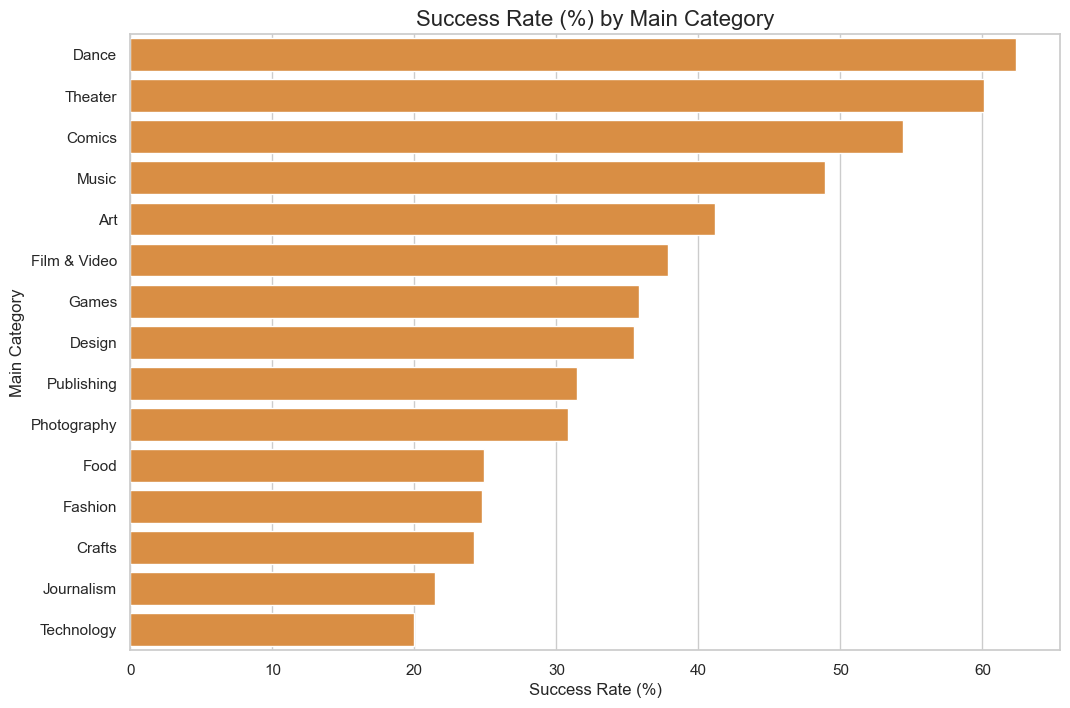

In [26]:
# Calculate and plot success rate by Main Category
# Group by category, get normalized value counts, select 'successful', sort
category_success = (df.groupby('main_category')['target']
                      .value_counts(normalize=True)
                      .loc[:, 'successful']
                      .sort_values(ascending=False) * 100)

plt.figure(figsize=(12, 8))
sns.barplot(x=category_success.values, y=category_success.index, color=colors['successful'])
plt.title('Success Rate (%) by Main Category', fontsize=16)
plt.xlabel('Success Rate (%)')
plt.ylabel('Main Category')
plt.show()

In [14]:
# Count projects by main category and sort descending
df['main_category'].value_counts().sort_values(ascending=False)

main_category
Film & Video    62365
Music           49249
Publishing      39080
Games           34939
Technology      32185
Design          29762
Art             27959
Food            24416
Fashion         22562
Theater         10871
Comics          10743
Photography     10730
Crafts           8733
Journalism       4723
Dance            3749
Name: count, dtype: int64

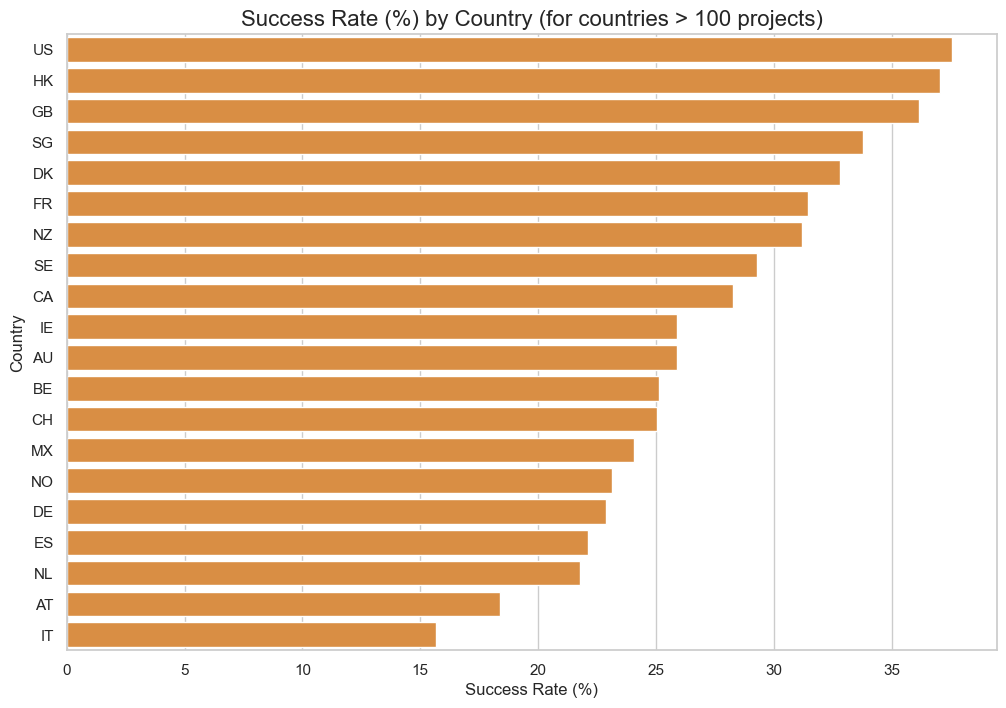

In [27]:
# 2. Calculate and plot success rate by Country
# Filter out countries with very few projects (e.g., < 100)
country_counts = df['country'].value_counts()
common_countries = country_counts[country_counts > 100].index
df_common_countries = df[df['country'].isin(common_countries)]

country_success = (df_common_countries.groupby('country')['target']
                     .value_counts(normalize=True)
                     .loc[:, 'successful']
                     .sort_values(ascending=False) * 100)

plt.figure(figsize=(12, 8))
sns.barplot(x=country_success.values, y=country_success.index, color=colors['successful'])
plt.title('Success Rate (%) by Country (for countries > 100 projects)', fontsize=16)
plt.xlabel('Success Rate (%)')
plt.ylabel('Country')
plt.show()

The project's category is a huge factor in its success. 'Dance', 'Comics', and 'Theater' have the highest success rates (all > 55%), while 'Technology', 'Journalism', and 'Crafts' have the lowest. 'US' has the highest rate, while 'IT' has the lowest among common countries.

Null Hypothesis ($H_0$): There is no difference in the mean log_usd_goal_real between successful and unsuccessful projects.Alternative Hypothesis ($H_a$): The mean log_usd_goal_real of successful projects is lower than the mean log_usd_goal_real of unsuccessful projects.

In [16]:
# Separate the two groups for the t-test
successful_goals = df[df['target'] == 'successful']['log_usd_goal_real']
unsuccessful_goals = df[df['target'] == 'unsuccessful']['log_usd_goal_real']

# Perform Welch's T-test (assumes unequal variances, which is safer)
# 'alternative='less'' checks if the mean of the first group (successful) is less than the second (unsuccessful)
t_stat, p_value = stats.ttest_ind(successful_goals, unsuccessful_goals, equal_var=False, alternative='less')

print("--- Two-Sample T-Test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: The p-value ({p_value}) is less than {alpha}.")
    print("We REJECT the null hypothesis.")
    print("There is a statistically significant evidence that successful projects have a lower mean funding goal.")
else:
    print(f"\nConclusion: The p-value ({p_value}) is not less than {alpha}.")
    print("We FAIL TO REJECT the null hypothesis.")

--- Two-Sample T-Test Results ---
T-statistic: -146.0289
P-value: 0.0

Conclusion: The p-value (0.0) is less than 0.05.
We REJECT the null hypothesis.
There is a statistically significant evidence that successful projects have a lower mean funding goal.


Correlation Heatmap

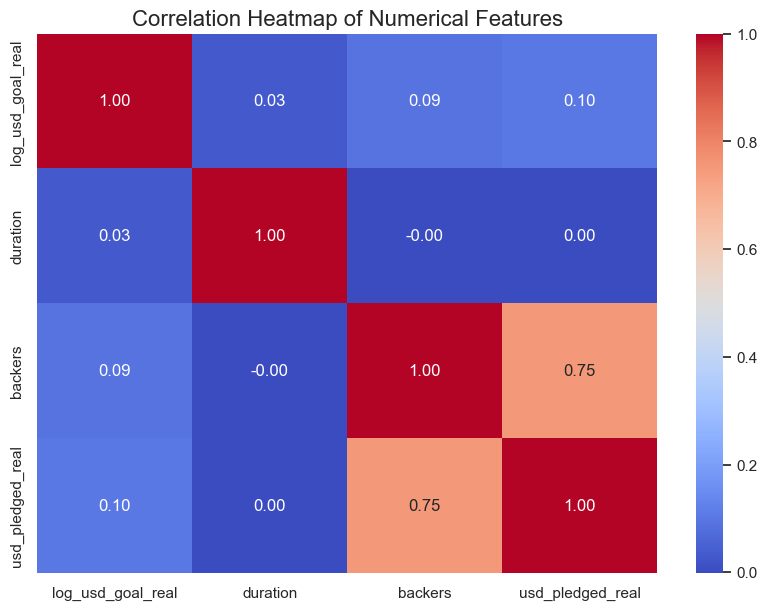

In [17]:
# Select key numerical features for the correlation matrix
corr_features = ['log_usd_goal_real', 'duration', 'backers', 'usd_pledged_real']
corr_matrix = df[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

backers and usd_pledged_real: There is a very strong positive correlation (0.75). This makes sense: the more backers a project has, the more money it raises.

log_usd_goal_real and backers: There is a weak positive correlation (0.03).

duration: Has very weak correlations with all other features.

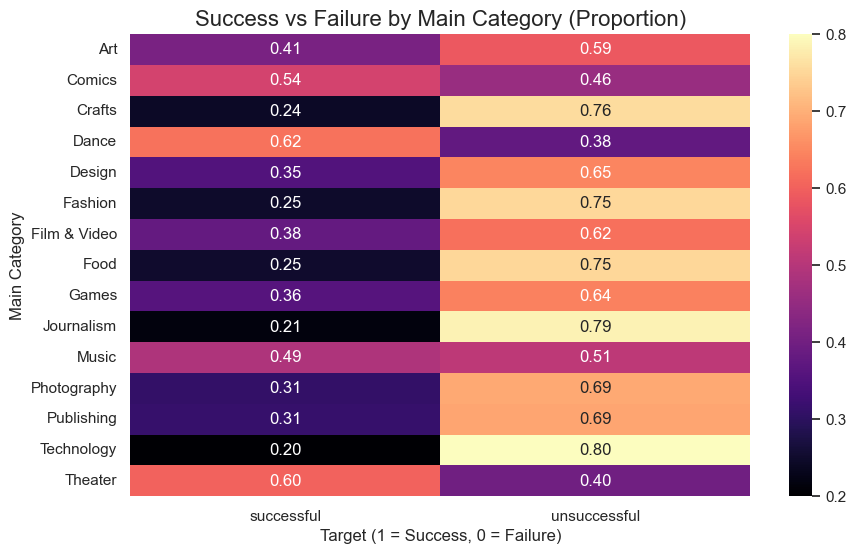

In [18]:
# category vs target (proportion of success/failure)
cat_ct = pd.crosstab(df['main_category'], df['target'], normalize='index')

plt.figure(figsize=(10,6))
sns.heatmap(cat_ct, annot=True, fmt=".2f", cmap="magma")
plt.title("Success vs Failure by Main Category (Proportion)", fontsize=16)
plt.ylabel("Main Category")
plt.xlabel("Target (1 = Success, 0 = Failure)")
plt.show()

Does the timing of the project affect its success rate?

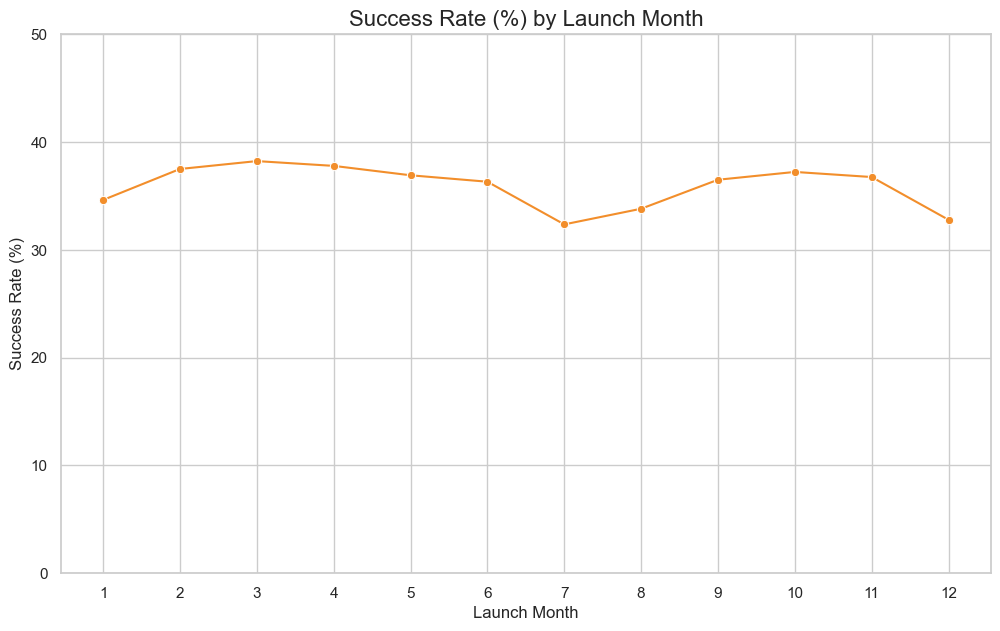

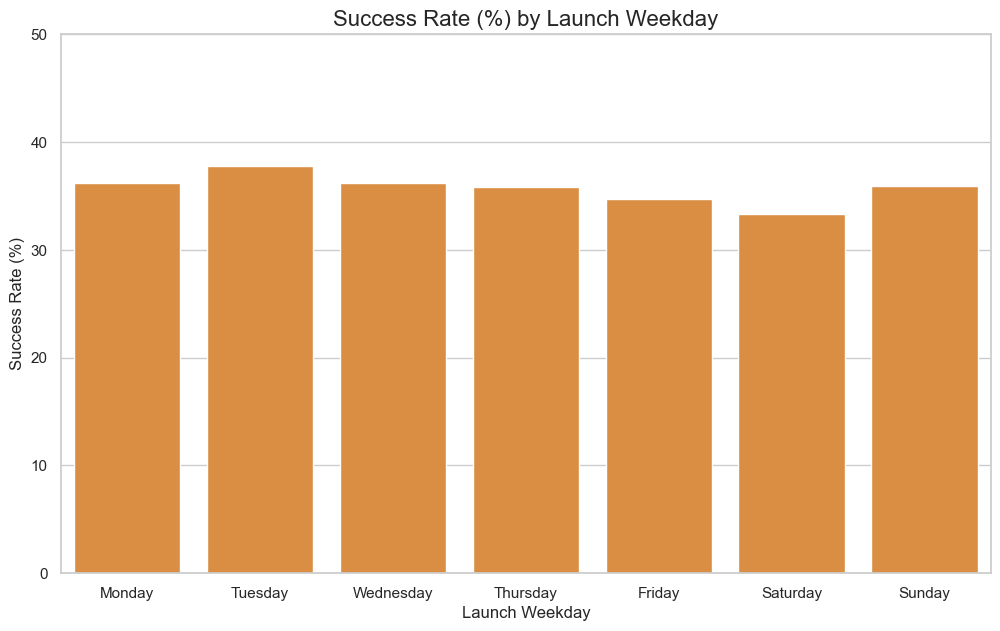

In [32]:
df['launch_month'] = df['launched'].dt.month
df['launch_weekday'] = df['launched'].dt.day_name()

# Plot Success Rate by Launch Month
plt.figure(figsize=(12, 7))
month_success = (df.groupby('launch_month')['target']
                   .value_counts(normalize=True)
                   .loc[:, 'successful'] * 100)

sns.lineplot(x=month_success.index, y=month_success.values, marker='o', color=colors['successful'])
plt.title('Success Rate (%) by Launch Month', fontsize=16)
plt.xlabel('Launch Month')
plt.ylabel('Success Rate (%)')
plt.xticks(range(1, 13))
plt.ylim(0, 50) # Set y-axis to start from 0 for better comparison
plt.show()

# Plot Success Rate by Launch Weekday
plt.figure(figsize=(12, 7))
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_success = (df.groupby('launch_weekday')['target']
                     .value_counts(normalize=True)
                     .loc[:, 'successful']
                     .loc[weekday_order] * 100)

sns.barplot(x=weekday_success.index, y=weekday_success.values, color=colors['successful'])
plt.title('Success Rate (%) by Launch Weekday', fontsize=16)
plt.xlabel('Launch Weekday')
plt.ylabel('Success Rate (%)')
plt.ylim(0, 50)
plt.show()

Success rates tend to be the worst in July.

Weekday: There is not a huge difference, but projects launched on Saturdays seem to have a lower success rate.

Multivariate Analysis (Pair Plot)

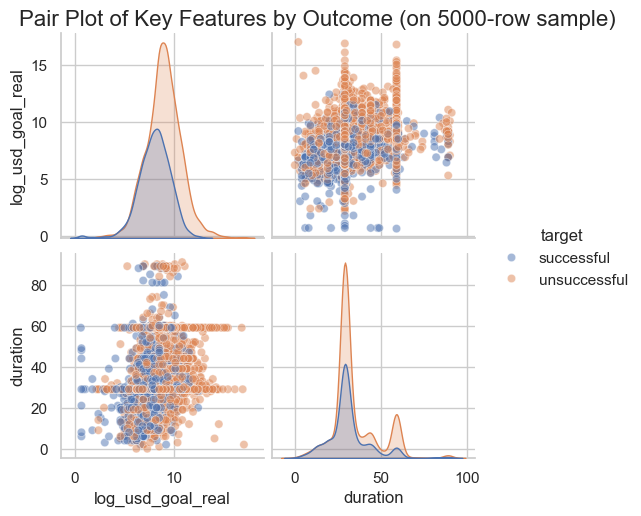

In [20]:
# Create a small sample for the pairplot
df_sample = df.sample(n=5000, random_state=42)

# Define the features for the plot
pair_features = ['log_usd_goal_real', 'duration', 'target']

# Create the pairplot
sns.pairplot(df_sample[pair_features], hue='target', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot of Key Features by Outcome (on 5000-row sample)', y=1.02, fontsize=16)
plt.show()